In [2]:
"""
As a microbiologist teaching myself to code, this is 
my first independent data analysis project. I know it is a simple
linear regression model and has limitations of which I have documented 
below. I am sharing this not as a finished product but as evidence of
my learning journey and dedication to improvement.
"""

'\nAs a microbiologist teaching myself to code, this is \nmy first independent data analysis project. I know it is a simple\nlinear regression model and has limitations of which I have documented \nbelow. I am sharing this not as a finished product but as evidence of\nmy learning journey and dedication to improvement.\n'

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
import matplotlib.pyplot as plt

In [7]:
from scipy import stats

In [8]:
malaria_data = pd.read_csv('incidence-of-malaria.csv')

In [9]:
#View the top of malaria_data dataframe
malaria_data.head()

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)"
0,Afghanistan,AFG,2000,84.48
1,Afghanistan,AFG,2001,83.83
2,Afghanistan,AFG,2002,83.79
3,Afghanistan,AFG,2003,70.81
4,Afghanistan,AFG,2004,39.41


In [10]:
'''
slicing by rows works in getting the data for Nigeria. This may
not work well for large data that has not been ordered.
'''
#Nigeria_data = malaria_data.loc[1827:1849]

'\nslicing by rows works in getting the data for Nigeria. This may\nnot work well for large data that has not been ordered.\n'

In [11]:
Nigeria = malaria_data[malaria_data['Entity']== 'Nigeria'].copy()

In [12]:
print(Nigeria)

       Entity Code  Year  Incidence of malaria (per 1,000 population at risk)
1825  Nigeria  NGA  2000                                             401.79  
1826  Nigeria  NGA  2001                                             394.49  
1827  Nigeria  NGA  2002                                             381.75  
1828  Nigeria  NGA  2003                                             382.09  
1829  Nigeria  NGA  2004                                             390.12  
1830  Nigeria  NGA  2005                                             395.90  
1831  Nigeria  NGA  2006                                             398.57  
1832  Nigeria  NGA  2007                                             400.61  
1833  Nigeria  NGA  2008                                             402.01  
1834  Nigeria  NGA  2009                                             389.96  
1835  Nigeria  NGA  2010                                             363.36  
1836  Nigeria  NGA  2011                                        

<Axes: xlabel='Year'>

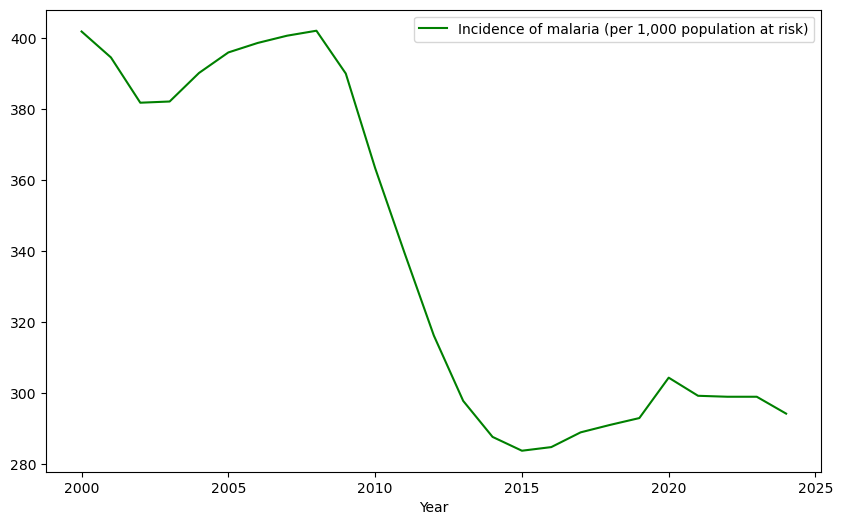

In [13]:
Nigeria.plot.line(x='Year', y='Incidence of malaria (per 1,000 population at risk)', figsize=(10, 6), color='green')

<Axes: xlabel='Year', ylabel='Incidence of malaria (per 1,000 population at risk)'>

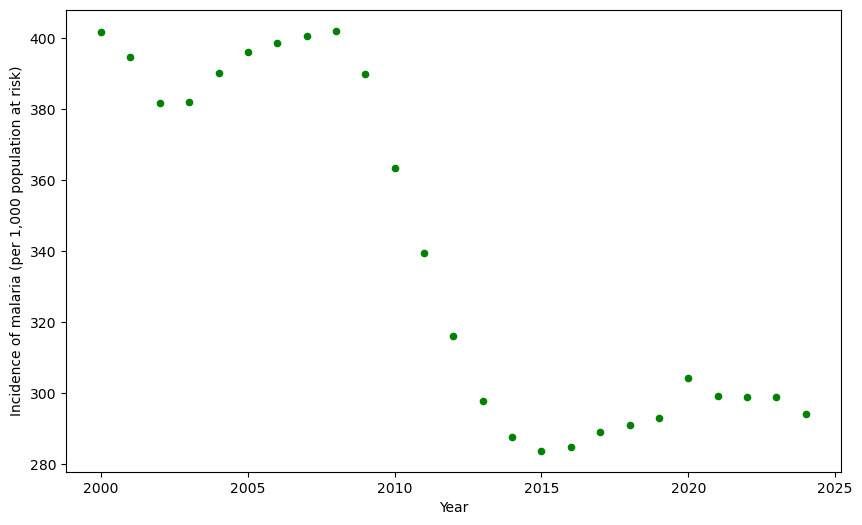

In [14]:
Nigeria.plot.scatter(x='Year', y='Incidence of malaria (per 1,000 population at risk)', figsize=(10, 6), color='green')

In [14]:
#Making a prediction for 2030

In [16]:
#finding slope, intercept, r_value, p_value, standard error
slope1, intercept1, r_value, p_value, std_err = stats.linregress(Nigeria['Year'], Nigeria['Incidence of malaria (per 1,000 population at risk)'])

In [17]:
print(f" Slope: {slope1:.4f}, Intercept: {intercept1:.4f}, r:{r_value:.1f}")

 Slope: -5.7718, Intercept: 11952.0876, r:-0.9


In [18]:
'''
y = mx + b
where y = incidence we are predicting 
m= slope
x = year(2030 in this case)
b = intercept
'''

'\ny = mx + b\nwhere y = incidence we are predicting \nm= slope\nx = year(2030 in this case)\nb = intercept\n'

In [19]:
year_2030 = 2030
predicted_2030 = slope1 * year_2030 + intercept1

print(f"Predicted incidence for 2030: {predicted_2030:.2f}")



Predicted incidence for 2030: 235.29


In [20]:
# Create a simple trend line for all years
Nigeria['trend'] = slope1 * Nigeria['Year'] + intercept1

In [21]:
# Show predicted data vs actual years
print(Nigeria[['Year', 'Incidence of malaria (per 1,000 population at risk)', 'trend']])

      Year  Incidence of malaria (per 1,000 population at risk)       trend
1825  2000                                             401.79    408.441477
1826  2001                                             394.49    402.669654
1827  2002                                             381.75    396.897831
1828  2003                                             382.09    391.126008
1829  2004                                             390.12    385.354185
1830  2005                                             395.90    379.582362
1831  2006                                             398.57    373.810538
1832  2007                                             400.61    368.038715
1833  2008                                             402.01    362.266892
1834  2009                                             389.96    356.495069
1835  2010                                             363.36    350.723246
1836  2011                                             339.51    344.951423
1837  2012  

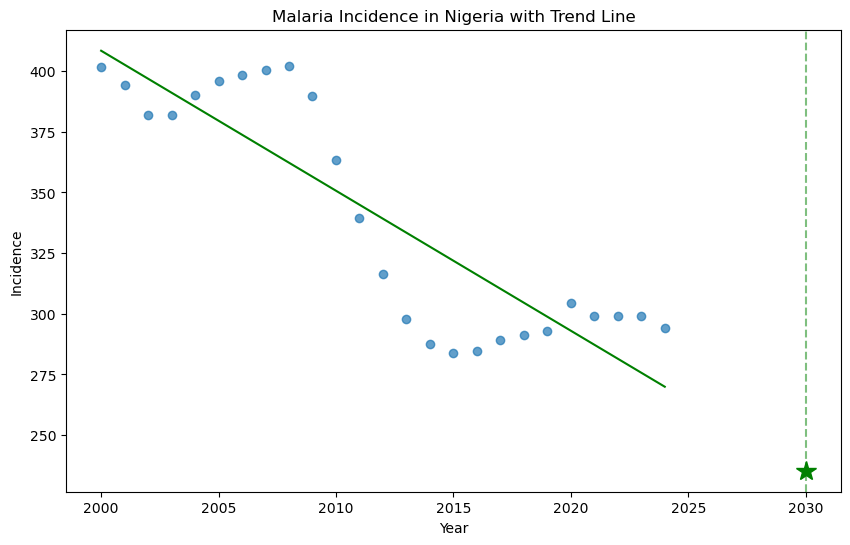

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(Nigeria['Year'], Nigeria['Incidence of malaria (per 1,000 population at risk)'], label='Actual', alpha=0.7)
plt.plot(Nigeria['Year'], Nigeria['trend'], 'green', label=f'Trend (slope={slope1:.4f})')
plt.axvline(x=2030, color='green', linestyle='--', alpha=0.5, label='2030 prediction')
plt.plot(2030, predicted_2030, 'g*', markersize=15, label=f'Predicted: {predicted_2030:.2f}')
plt.xlabel('Year')
plt.ylabel('Incidence')
plt.title('Malaria Incidence in Nigeria with Trend Line')
plt.show()

In [23]:
#Create a linear regression model
model = LinearRegression(fit_intercept=True)
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
#Assign the independent variable(year) to X by drop all other varialbes
X = Nigeria.drop(['Incidence of malaria (per 1,000 population at risk)', 'trend', 'Entity', 'Code'], 
                          axis=1)



In [25]:
#Assign dependent variable to y
y = Nigeria['Incidence of malaria (per 1,000 population at risk)']
y.shape


(25,)

In [26]:
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
#find coefficient. A negative coeffecient indicates an inverse relationship between 
#the independent variable X and the dependent variable y.  
model.coef_

array([-5.77182308])

In [28]:
model.intercept_

np.float64(11952.087630769225)

In [29]:
#Predicting for years 2025 - 2030
Xfit = pd.DataFrame({'Year': [2025, 2026, 2027, 2028, 2029, 2030]})

In [30]:
yfit = model.predict(Xfit)

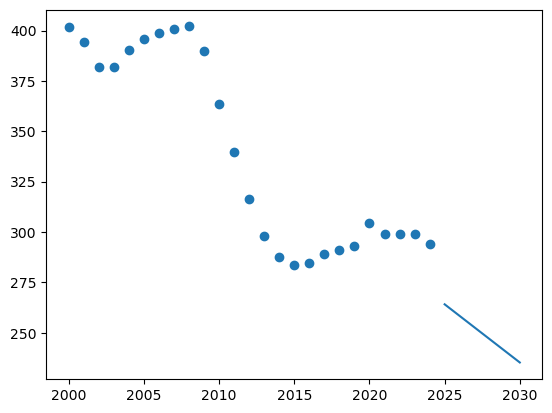

In [31]:
plt.scatter(X, y)
plt.plot(Xfit, yfit);

In [37]:
"""
Linear regression assumes a constant rate of change.
It fails to consider external factors like seasons and malaria interventions.
Model assumes a constant rate of change as it predicts 2030.
Test on 2017 - 2024 shows an error in predictions.
"""

'\nLinear regression assumes a constant rate of change.\nIt fails to consider external factors like seasons and malaria interventions.\nModel assumes a constant rate of change as it predicts 2030.\nTest on 2017 - 2024 shows an error in predictions.\n'